In [1]:
#pyg or py data, dataset, dataloader?
# dictionary or Data as output of PROTACDataset?
    #What works with the data loader?
    #What works with pyg funcitons such as num_node_features?



# import torch dataset and dataloader

#from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import os
# Import from_smiles from pytorch geometric
from torch_geometric.utils import from_smiles
from torch_geometric.data import Data, Dataset, InMemoryDataset
from torch_geometric.loader import DataLoader
from all_functions import get_node_labels, process_boundaries_to_substructure_labels_v2_single
from all_functions import make_graph_with_pos, mol_to_simple_graph, graph_to_mol
from rdkit import Chem


    

class ProtacDataset(InMemoryDataset):

    def __init__(self, protac_input, transform=None, predict=False):
        self.predict = predict
        
        if self.predict: #Mode between training and prediction
            if isinstance(protac_input, list): #2 allowed types of input when predicting: List or Dataframe
                self.protac_smiles = protac_input #List with str
            elif isinstance(protac_input, str):
                self.protac_smiles = [protac_input] #make into List with str
            else:
                #self.protac_df = protac_input
                self.protac_smiles = protac_input['PROTAC SMILES'].tolist()                  # OBS!! Apply remove_stereo() !  

        else:  #training mode. Requires input to be Dataframe                                
            #self.protac_df = protac_input
            self.protac_smiles = protac_input['PROTAC SMILES'].tolist()   
            self.poi_smiles = protac_input['POI SMILES'].tolist()
            self.e3_smiles = protac_input['E3 SMILES'].tolist()
            self.node_boundaries = [get_node_labels(smiles, poi_smile, e3_smile) for smiles, poi_smile, e3_smile in zip(self.protac_smiles, self.poi_smiles, self.e3_smiles)]
            #self.substructure_labels = 

    def __len__(self):
        return len(self.protac_smiles)
    
    def __getitem__(self, idx):
        elem = from_smiles(self.protac_smiles[idx])
        elem["x"]=elem["x"].type(torch.float32)
        elem["edge_index"]=elem["edge_index"].type(torch.int64)
        elem["edge_attr"]=elem["edge_attr"].type(torch.float32)
        if not self.predict: #meaning if in training mode
            elem["node_boundaries"] = self.node_boundaries[idx]


        return elem


/home/knkn308/.conda/envs/env-protac-toolkit/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
protac_pub_trainset_df = pd.read_csv('../../data/augmented/protac_pub_testset_testing.csv')
protac_pub_testset_df = pd.read_csv('../../data/augmented/protac_pub_trainset_testing.csv')
train_set_pub = ProtacDataset(protac_input=protac_pub_trainset_df)

In [3]:
"""print(train_set_pub[0])
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_set_pub, batch_size=32, shuffle=True)
x = next(iter(train_loader))
print(x.node_boundaries)

len(train_set_pub[0].node_boundaries) #0 8, 1 7

print(x.node_boundaries[62+7])

#for i in range(20):
#    print(x.node_boundaries[i])"""

'print(train_set_pub[0])\nfrom torch_geometric.loader import DataLoader\ntrain_loader = DataLoader(train_set_pub, batch_size=32, shuffle=True)\nx = next(iter(train_loader))\nprint(x.node_boundaries)\n\nlen(train_set_pub[0].node_boundaries) #0 8, 1 7\n\nprint(x.node_boundaries[62+7])\n\n#for i in range(20):\n#    print(x.node_boundaries[i])'

In [4]:
#print(train_set_pub[0])
#train_set_pub[0].node_boundaries.dtype

In [5]:
from torch_geometric.nn import GraphConv
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import networkx as nx
import matplotlib.pyplot as plt


#optimizer = optim.Adam(model.parameters(), lr=0.001)

#GCNConv worked well before, with a test accuracy of around 0.93
#GraphConv: maybe converges faster?
class PROTACSplitter(torch.nn.Module):
    def __init__(self, node_feature_dim, edge_feature_dim):
        super(PROTACSplitter, self).__init__()
        self.conv1 = GraphConv(node_feature_dim, 16)# edge_dim=edge_feature_dim)
        self.linear_layer = torch.nn.Linear(16, 3)  # Output layer for 3 classes
    
    #def forward(self, data_batch):
    def forward(self, node_attr, edge_index):
        #data = batch['pyg_data']
        #print(f"data_batch.x: {data_batch.x}")
        #print(f"data_batch.edge_index: {data_batch.edge_index}")
        #z = self.conv1(data_batch.x, data_batch.edge_index)#, edge_attr)
        z = self.conv1(node_attr, edge_index)#, edge_attr)
        z = F.relu(z)
        y = self.linear_layer(z)
        return y
        
    def train_model(self, training_data, optimizer=optim.Adam, lr = 0.001, batch_size=32, criterion=nn.CrossEntropyLoss(), shuffle=True, epochs=5, get_substructure_acc=False):
        self.train()
        train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=shuffle)
        optimizer=optimizer(self.parameters(), lr=lr)
        optimizer.zero_grad()

        avg_loss_list = []
        num_protacs = len(training_data)
        for epoch in range(epochs):
            total_loss = 0
            for train_data in train_loader:
                node_attr=train_data.x
                edge_index = train_data.edge_index
                raw_boundary_prediction = self.forward(node_attr, edge_index)             # "RuntimeError: mat1 and mat2 must have the same dtype"
                node_class_targets = train_data['node_boundaries']
                loss = criterion(raw_boundary_prediction, node_class_targets) 
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if (epoch+1) % 5 == 0:
                print(f"Avg train loss (epoch: {epoch+1}): ", avg_loss_list[-1])
            avg_loss_list.append(total_loss / num_protacs) 

        return avg_loss_list

    def get_protac_data(self, protac_smiles):
        protac_data = ProtacDataset(protac_input=protac_smiles, predict=True)
        return protac_data

    def predict_substructure(self, protac_smiles=[], protac_data=None, raw_boundary_prediction=None): #Define protac_smiles or protac_data
        #get protac_data and protac_smiles 
        if protac_smiles != []:
            protac_data = ProtacDataset(protac_input=protac_smiles, predict=True)
            #protac_data_batch = DataLoader(protac_data, batch_size=len(protac_data), shuffle=False)
        else:
            for protac_datapoint in protac_data:
                protac_smiles.append(protac_datapoint.smiles)
        self.eval() 
        with torch.no_grad():
            for protac_datapoint in protac_data:
                if raw_boundary_prediction is None:
                    raw_boundary_prediction = self.forward(protac_datapoint.x, protac_datapoint.edge_index)
                class_predictions = process_boundaries_to_substructure_labels_v2_single(protac_smiles, raw_boundary_prediction)
                    #Update the process_boundaries_to_substructure_labels_v2_single() to not rely on shortest path. Later on, adapt so it can take a batch.
                probabilities = F.softmax(raw_boundary_prediction, dim=1)      
        return class_predictions, probabilities

    def get_substructure_smiles(self, protac_smiles, class_predictions):
        #look at 3_evaluation.ipynb or ...
        
        protac_mol = Chem.MolFromSmiles(protac_smiles)
        protac_graph = mol_to_simple_graph(protac_mol)
        substructure_smiles = []
        node_indices_substructure = [[], [], []]
        class_predictions_list = class_predictions.tolist()
        for substructure_idx in [0, 1, 2]:
            node_indices_substructure[substructure_idx] = [i for i, x in enumerate(class_predictions_list) if x == substructure_idx]
            substructure_graph = protac_graph.subgraph(node_indices_substructure[substructure_idx])
            substructure_mol = graph_to_mol(substructure_graph)  #OBS! Need to fix graph_to_mol()
            #display(substructure_mol)
            substructure_smiles.append(Chem.MolToSmiles(substructure_mol))
        return substructure_smiles

        """node_indices_substructure = [[], [], []]
        #for node_idx, label in enumerate(class_predictions):
        node_indices_substructure[0] = [i for i, x in enumerate(class_predictions_list) if x == 0]
        node_indices_substructure[1] = [i for i, x in enumerate(class_predictions_list) if x == 1]
        node_indices_substructure[2] = [i for i, x in enumerate(class_predictions_list) if x == 2]
        #print(node_indices_substructure)
        poi_graph = protac_graph.subgraph(node_indices_substructure[0])
        linker_graph = protac_graph.subgraph(node_indices_substructure[1])
        e3_graph = protac_graph.subgraph(node_indices_substructure[2])
        poi_mol = graph_to_mol(poi_graph) 
        linker_mol = graph_to_mol(linker_graph)                               
        e3_mol = graph_to_mol(e3_graph)
        #display(poi_mol)
        #display(linker_mol)
        #display(e3_mol)
        poi_smile = Chem.MolToSmiles(poi_mol)
        linker_smile = Chem.MolToSmiles(linker_mol)
        e3_smile = Chem.MolToSmiles(e3_mol)
        return [poi_smile, linker_smile, e3_smile]"""
        
    
    def visualize_prediction(self, protac_smiles=[], protac_data=None):
        if protac_smiles == []:
            for protac_datapoint in protac_data:
                protac_smiles.append(protac_datapoint.smiles) #if you feed protac_data instead
        for smi in protac_smiles:
            if len(smi) == 1:
                smi = protac_smiles #assume protac_smiles is a str
            class_predictions, _ = self.predict_substructure(protac_smiles=smi, protac_data=protac_data)
            G, pos = make_graph_with_pos(smi)
            colors = []
            for label in class_predictions:
                if label == 0: #POI
                    colors.append('red')
                elif label == 1: #linker
                    colors.append('gray')
                elif label == 2: #E3
                    colors.append('blue')
            
            #print(len(colors))
            #print(pos)
            #print(len(G))
            nx.draw_networkx(G, pos=pos,  node_color=colors, with_labels=False, node_size = 50)
            plt.axis('equal')

    #def exact_boundary_accuracy()   #How often the boundaries are exactly correct. Accuracy for E3, POI and both at same time.

    #def grace_boundary_accuracy():  #How often the boundary is "close" to the right split

    #def poi_e3_identity_accuracy(): #How often the boundaries are placed on the right side <=> How often the POI and E3 are not swapped.

    #def substructure_accuracy()     #(num correct nodes / num predicted nodes) for POI, Linker and E3
        #process_boundaries_to_substructures(raw_boundary_prediction, node_class_targets)

    #def self_consistency()          #How many variants splits there are for the each specific POI, E3 and Linker. Ideally 1 variant, which is the correct one.

    

In [6]:
node_feature_dim = train_set_pub.num_node_features
edge_feature_dim = train_set_pub.num_edge_features 
model = PROTACSplitter(node_feature_dim, edge_feature_dim)

In [7]:
protac_data = model.get_protac_data(protac_pub_trainset_df["PROTAC SMILES"].tolist())
print(protac_data)

ProtacDataset(27)


In [8]:
model.train_model(training_data=train_set_pub, batch_size=16, epochs = 20, lr=0.001)
pass

Avg train loss (epoch: 5):  0.22740115059746635
Avg train loss (epoch: 10):  0.14179095515498408
Avg train loss (epoch: 15):  0.06618924494142886
Avg train loss (epoch: 20):  0.025063144939917105


tensor([2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1])


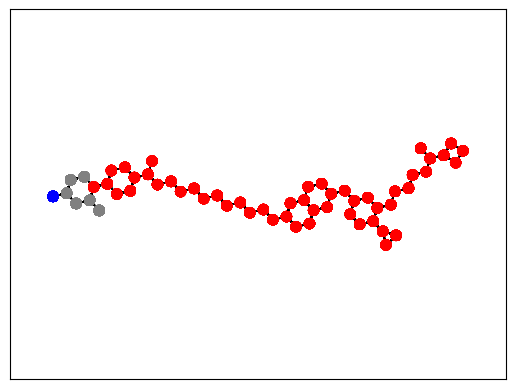

In [9]:
smi = train_set_pub[20].smiles
class_predictions, probabilities = model.predict_substructure(protac_smiles=smi) 
print(class_predictions)
model.visualize_prediction(smi)


In [10]:
substructure_smiles = model.get_substructure_smiles(smi, class_predictions)  
poi_smiles = substructure_smiles[0]
linker_smiles = substructure_smiles[1]
e3_smiles = substructure_smiles[2]
display(Chem.MolFromSmiles(poi_smiles))
display(Chem.MolFromSmiles(linker_smiles))
display(Chem.MolFromSmiles(e3_smiles))


RuntimeError: Range Error
	atomIdx2
	Violation occurred on line 378 in file Code/GraphMol/RWMol.cpp
	Failed Expression: 54 < 51
	RDKIT: 2023.03.3
	BOOST: 1_78


In [43]:


model = PROTACSplitter()
for batch in DataLoader(train_set_pub, batch_size=32):
    # batch['protac_smiles'] = (batch_size, 1024)
    y_hat = model(batch)
    loss = loss_fn(y_hat, batch['node_boundaries'])
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    # Metric
    y_hat = torch.argmax(y_hat, dim=1) # (batch_size, num_nodes) -> (batch_size, 1)
    acc = (y_hat == batch['node_boundaries']).sum() / len(y_hat)


TypeError: PROTACSplitter.__init__() missing 2 required positional arguments: 'node_feature_dim' and 'edge_feature_dim'